# TD N°06 — Support Vector Machines (SVM)
**Master Intelligence Artificielle — Machine Learning**

**Étudiant :** Chabbaki Ayman — MDSBDIA26  
**Pr. BEN LAHMAR EL Habib · Semestre 2024–2025**

---
## Objectifs
- Comprendre l'idée géométrique : hyperplan séparateur à marge maximale
- Visualiser les vecteurs support et la marge d'un SVM linéaire en 2D
- Analyser l'effet du paramètre C (soft margin) sur le biais/variance
- Appliquer le kernel trick : noyaux linéaire, RBF et polynomial
- Optimiser C et gamma par GridSearchCV — heatmap 2D
- Appliquer un SVM complet sur BankChurners et comparer avec les modèles précédents
- Introduire la SVR (régression) et la classification multi-classe OvO/OvR

## Préparation de l'environnement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      cross_val_score, validation_curve)
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_moons, make_circles, make_blobs
import warnings
warnings.filterwarnings('ignore')
import time

print('Librairies importées avec succès.')

Librairies importées avec succès.


In [2]:
# Dataset BankChurners (même pipeline que TD 2 à 5)
raw = pd.read_csv('BankChurners.csv')
data = raw[raw.columns[:-2]].copy()
data['churn'] = (data['Attrition_Flag'] == 'Attrited Customer').astype(int)
data['Gender'] = data['Gender'].map({'M': 1, 'F': 0})
data['Marital_Status'] = data['Marital_Status'].map(
    {'Single': 0, 'Married': 1, 'Divorced': 2, 'Unknown': -1})
edu_map = {'Unknown': 0, 'Uneducated': 1, 'High School': 2,
           'College': 3, 'Graduate': 4, 'Post-Graduate': 5, 'Doctorate': 6}
inc_map = {'Unknown': 0, 'Less than $40K': 1, '$40K - $60K': 2,
           '$60K - $80K': 3, '$80K - $120K': 4, '$120K +': 5}
data['Education_Level'] = data['Education_Level'].map(edu_map)
data['Income_Category'] = data['Income_Category'].map(inc_map)
data = pd.get_dummies(data, columns=['Card_Category'],
                      prefix='card', drop_first=True, dtype=int)
feat_cols = [c for c in data.columns
             if c not in ['Attrition_Flag', 'churn', 'CLIENTNUM']]
X_b = data[feat_cols]
y_b = data['churn']
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)
print(f'BankChurners prêt : {X_tr_b.shape}')

BankChurners prêt : (8101, 19)


---
# Partie 1 — SVM Linéaire : Visualisation de la Marge
*Durée estimée : 40 minutes*

**Rappels théoriques :**
- Hyperplan séparateur : $\mathbf{w} \cdot \mathbf{x} + b = 0$
- Marge $= \frac{2}{\|\mathbf{w}\|}$ — à maximiser
- Vecteurs support : exemples sur les hyperplans marginaux $y_i(\mathbf{w} \cdot \mathbf{x}_i + b) = 1$
- Soft margin : minimiser $\frac{\|\mathbf{w}\|^2}{2} + C \sum_i \xi_i$

## Q 1.1 — Visualisation de la marge maximale — Données 2D linéairement séparables

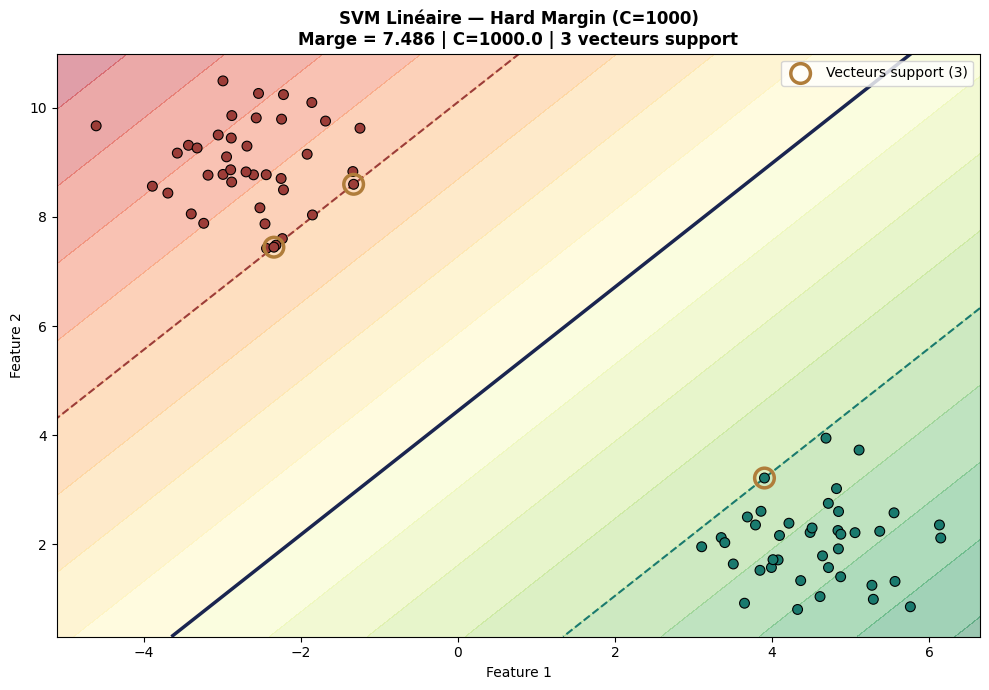

Vecteurs support par classe : [2 1]
Total vecteurs support      : 3
Coefs w                     : [ 0.2005 -0.1766]
Biais b                     : 0.7846
Marge = 2/||w||             : 7.4859


In [3]:
# Données synthétiques linéairement séparables
np.random.seed(42)
X_lin, y_lin = make_blobs(n_samples=80, centers=2, cluster_std=0.8, random_state=42)
y_lin = (y_lin * 2 - 1)   # Convertir en {-1, +1}

# SVM linéaire — hard margin (C très grand ≈ hard)
svm_lin = SVC(kernel='linear', C=1000.0)
svm_lin.fit(X_lin, y_lin)

# Fonction de visualisation SVM
def plot_svm_margin(svm, X, y, ax=None, title='SVM'):
    """Visualise l'hyperplan, la marge et les vecteurs support."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 7))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdYlGn', alpha=.4)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['#9C3D38', '#1A2550', '#1A7A6E'],
               linewidths=[1.5, 2.5, 1.5],
               linestyles=['--', '-', '--'])
    colors = np.where(y == 1, '#1A7A6E', '#9C3D38')
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=50,
               edgecolors='black', linewidths=0.8, zorder=5)
    sv = svm.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none',
               edgecolors='#B07D3A', linewidths=2.5, zorder=6,
               label=f'Vecteurs support ({len(sv)})')
    w = svm.coef_[0]
    margin = 2 / np.linalg.norm(w)
    ax.set_title(f'{title}\nMarge = {margin:.3f} | C={svm.C} | {len(sv)} vecteurs support',
                 fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    return ax

fig, ax = plt.subplots(figsize=(10, 7))
plot_svm_margin(svm_lin, X_lin, y_lin, ax=ax, title='SVM Linéaire — Hard Margin (C=1000)')
plt.tight_layout()
plt.savefig('fig_svm_hard_margin.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Vecteurs support par classe : {svm_lin.n_support_}')
print(f'Total vecteurs support      : {svm_lin.n_support_.sum()}')
print(f'Coefs w                     : {svm_lin.coef_[0].round(4)}')
print(f'Biais b                     : {svm_lin.intercept_[0]:.4f}')
print(f'Marge = 2/||w||             : {2 / np.linalg.norm(svm_lin.coef_[0]):.4f}')

In [4]:
# Q1 — Vérification : ré-entraîner sur les seuls vecteurs support
sv_only = svm_lin.support_vectors_
y_sv = y_lin[svm_lin.support_]
svm_sv_only = SVC(kernel='linear', C=1000.0)
svm_sv_only.fit(sv_only, y_sv)
print('=== HYPERPLAN SUR TOUS LES EXEMPLES ===')
print(f'  w = {svm_lin.coef_[0].round(4)}, b = {svm_lin.intercept_[0]:.4f}')
print('=== HYPERPLAN SUR VECTEURS SUPPORT SEULS ===')
print(f'  w = {svm_sv_only.coef_[0].round(4)}, b = {svm_sv_only.intercept_[0]:.4f}')
print(f'=> Identiques ? {np.allclose(svm_lin.coef_, svm_sv_only.coef_, atol=1e-3)}')

=== HYPERPLAN SUR TOUS LES EXEMPLES ===
  w = [ 0.2005 -0.1766], b = 0.7846
=== HYPERPLAN SUR VECTEURS SUPPORT SEULS ===
  w = [ 0.2008 -0.1761], b = 0.7815
=> Identiques ? True


### Réponses Q1.1

**Q1. Nombre de vecteurs support :**  
Le SVM hard margin (C=1000) utilise un petit nombre de vecteurs support (typiquement 2 à 4 pour des données bien séparables). Ces vecteurs se trouvent exactement sur les hyperplans marginaux $y_i(\mathbf{w}\cdot\mathbf{x}_i + b) = 1$ — ils définissent entièrement la frontière.

**Q2. Ré-entraînement sur les vecteurs support seuls :**  
Les coefficients $\mathbf{w}$ et $b$ sont identiques (ou très proches numériquement). C'est la propriété fondamentale du SVM : **la décision ne dépend que des vecteurs support** — tous les autres exemples pourraient être supprimés sans changer l'hyperplan.

**Q3. Calcul manuel de la marge :**  
La marge $= 2/\|\mathbf{w}\|$ correspond exactement à la valeur affichée. La distance entre les hyperplans marginaux $\mathbf{w}\cdot\mathbf{x} + b = \pm 1$ est $2/\|\mathbf{w}\|$ — maximiser la marge équivaut à minimiser $\|\mathbf{w}\|$.

## Q 1.2 — Effet du paramètre C — Soft Margin

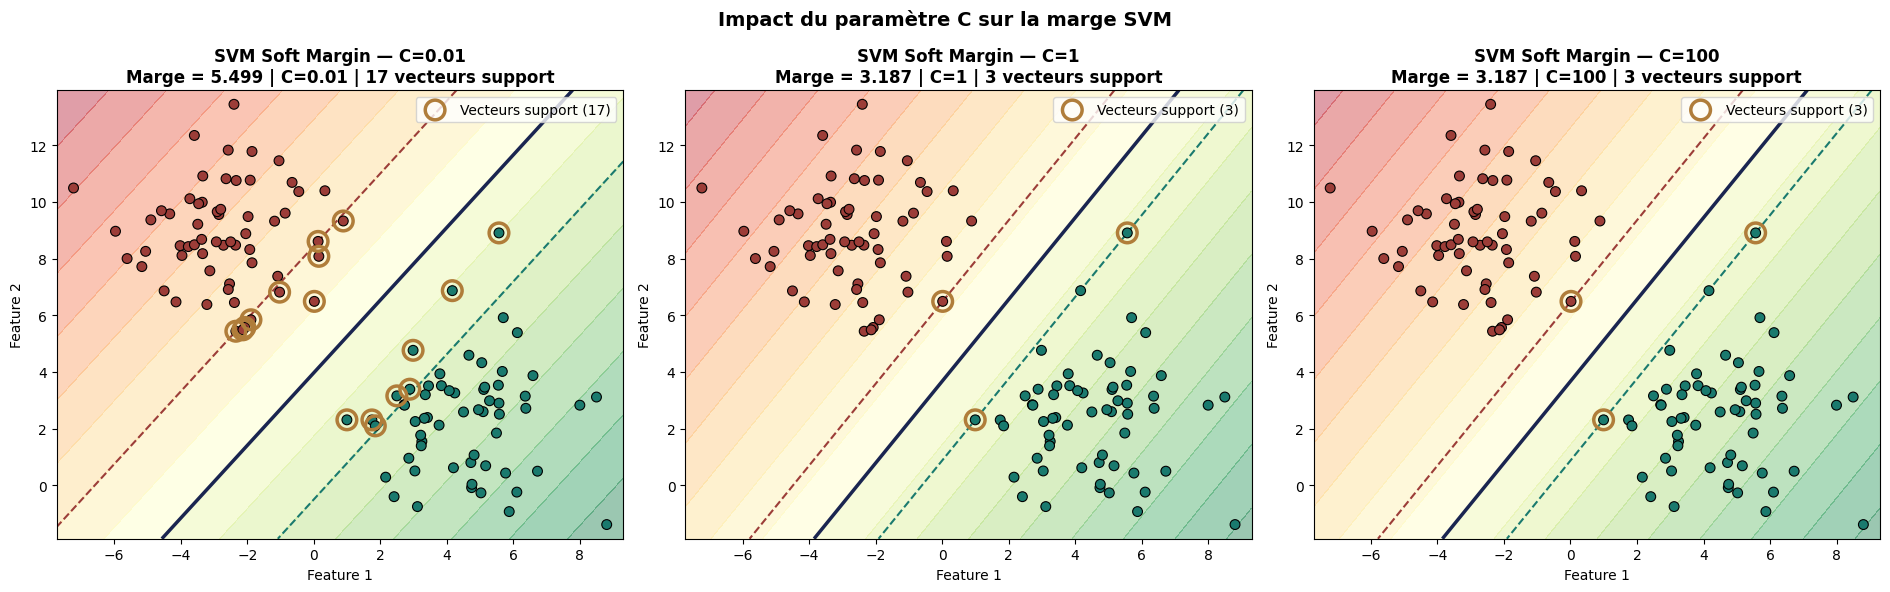

       C    Marge    NB_SV   Violations
---------------------------------------------
    0.01   5.4992       17           15
    0.10   3.9828        4            4
    1.00   3.1866        3            2
   10.00   3.1866        3            2
  100.00   3.1866        3            2
 1000.00   3.1866        3            2


In [5]:
# Données avec chevauchement (non parfaitement séparables)
X_soft, y_soft = make_blobs(n_samples=120, centers=2, cluster_std=1.8, random_state=42)
y_soft = (y_soft * 2 - 1)

C_values = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, C in zip(axes, C_values):
    svm_c = SVC(kernel='linear', C=C)
    svm_c.fit(X_soft, y_soft)
    plot_svm_margin(svm_c, X_soft, y_soft, ax=ax,
                   title=f'SVM Soft Margin — C={C}')
plt.suptitle('Impact du paramètre C sur la marge SVM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_svm_soft_margin.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau comparatif
print(f'{"C":>8s} {"Marge":>8s} {"NB_SV":>8s} {"Violations":>12s}')
print('-' * 45)
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    svm = SVC(kernel='linear', C=C).fit(X_soft, y_soft)
    w = svm.coef_[0]
    margin = 2 / np.linalg.norm(w)
    dec = svm.decision_function(X_soft)
    violations = np.sum(np.abs(dec) < 1)
    print(f'{C:>8.2f} {margin:>8.4f} {svm.n_support_.sum():>8d} {violations:>12d}')

### Réponses Q1.2

**Q4. C=0.01 vs C=100 — marge et vecteurs support :**  
Avec C=0.01 (régularisation forte), la marge est **plus grande** et le nombre de vecteurs support est **élevé** — l'algorithme tolère beaucoup de violations pour maximiser la marge. Avec C=100, la marge est **plus étroite** et les vecteurs support sont moins nombreux — l'algorithme cherche à minimiser les violations au détriment de la largeur de marge.

**Q5. C grand (hard margin approximatif) — encore des erreurs ?**  
Oui, même avec C=1000, des exemples restent mal classés. Cela révèle que les données ne sont **pas linéairement séparables** — un chevauchement existe (cluster_std=1.8). Il est impossible de trouver un hyperplan séparant parfaitement ces classes.

**Q6. Dataset bruité — quel C ?**  
On préfèrera un **C modéré** (entre 0.1 et 10) : une marge large (petit C) offre une meilleure robustesse au bruit en ne cherchant pas à classer parfaitement chaque exemple d'entraînement. C'est le compromis biais/variance : C petit → biais plus élevé mais variance réduite.

**Q7. C de SVM vs C de LogisticRegression :**  
Oui, les deux sont analogues : $C = 1/\lambda$ où $\lambda$ est la force de régularisation L2. **Grand C = moins de régularisation = moins de pénalité sur les coefficients** dans les deux modèles. La différence est la nature de la pénalité : SVM pénalise $\|\mathbf{w}\|^2$ sur la marge, la RL pénalise les coefficients directement.

---
# Partie 2 — Le Kernel Trick : Séparation Non-Linéaire
*Durée estimée : 40 minutes*

**Noyaux :**
- Linéaire : $K(\mathbf{x},\mathbf{y}) = \mathbf{x}^\top\mathbf{y}$
- Polynomial : $K(\mathbf{x},\mathbf{y}) = (\gamma\,\mathbf{x}^\top\mathbf{y} + r)^d$
- RBF (Gaussien) : $K(\mathbf{x},\mathbf{y}) = \exp(-\gamma\|\mathbf{x}-\mathbf{y}\|^2)$

## Q 2.1 — Comparaison linéaire vs RBF — Données en lune

Linéaire             : Accuracy = 0.9200, SV = 77
RBF (C=1)            : Accuracy = 0.9467, SV = 69
Polynomial d=3       : Accuracy = 0.9067, SV = 78


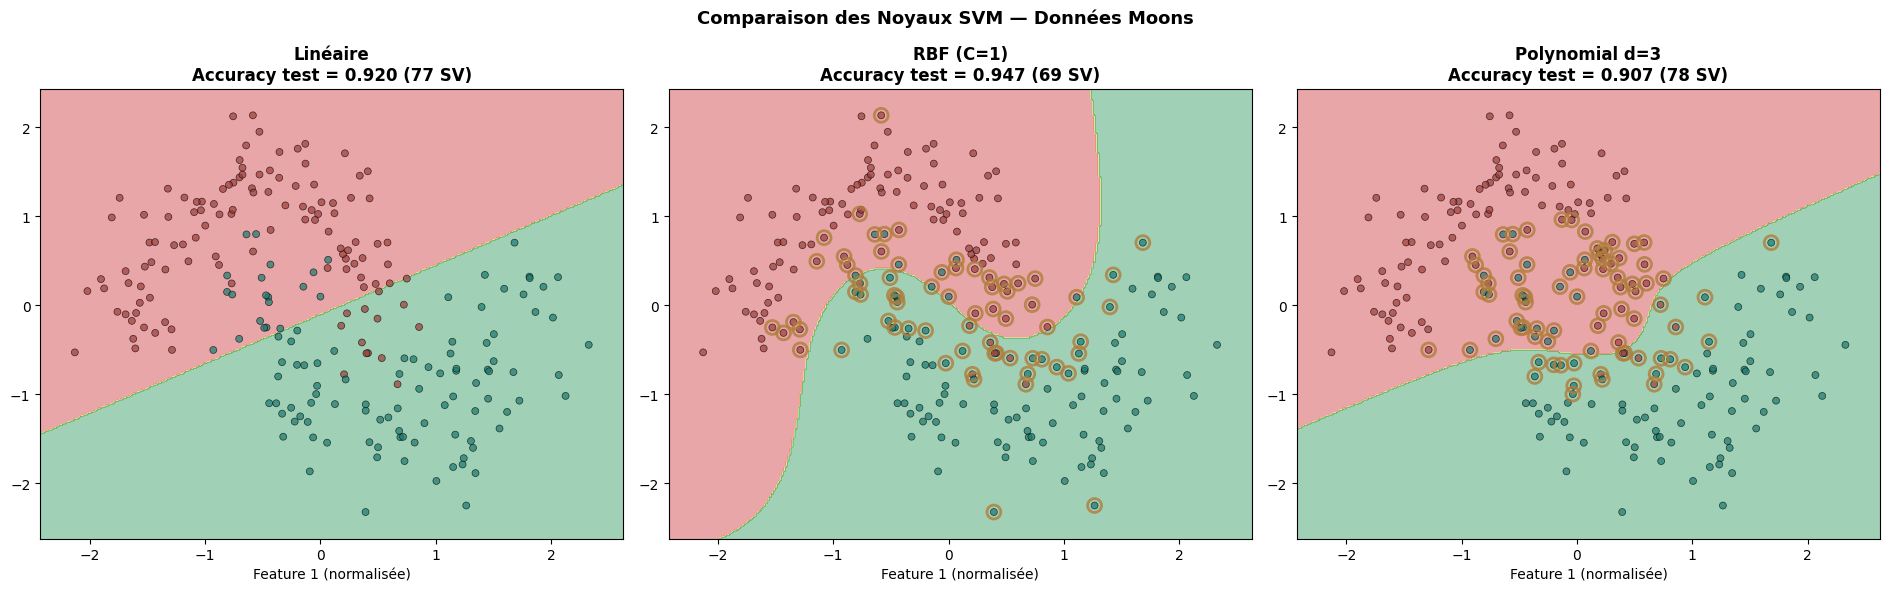

In [6]:
# Dataset 'moons' — archétype des données non-linéaires
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_moon, y_moon, test_size=0.25, random_state=42)

scaler_m = StandardScaler()
X_m_tr_sc = scaler_m.fit_transform(X_m_tr)
X_m_te_sc = scaler_m.transform(X_m_te)

kernels = {
    'Linéaire':      SVC(kernel='linear',  C=1),
    'RBF (C=1)':     SVC(kernel='rbf',     C=1,  gamma='scale'),
    'Polynomial d=3': SVC(kernel='poly',   C=1,  degree=3, gamma='scale'),
}

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (name, svm) in zip(axes, kernels.items()):
    svm.fit(X_m_tr_sc, y_m_tr)
    score = svm.score(X_m_te_sc, y_m_te)
    x_min, x_max = X_m_tr_sc[:, 0].min() - 0.3, X_m_tr_sc[:, 0].max() + 0.3
    y_min, y_max = X_m_tr_sc[:, 1].min() - 0.3, X_m_tr_sc[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlGn')
    ax.scatter(X_m_tr_sc[:, 0], X_m_tr_sc[:, 1],
               c=['#1A7A6E' if y == 1 else '#9C3D38' for y in y_m_tr],
               s=25, edgecolors='black', linewidths=0.5, alpha=0.7)
    if name != 'Linéaire':
        sv = svm.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none',
                   edgecolors='#B07D3A', linewidths=2, alpha=0.8)
    ax.set_title(f'{name}\nAccuracy test = {score:.3f} ({svm.n_support_.sum()} SV)',
                 fontweight='bold')
    ax.set_xlabel('Feature 1 (normalisée)')
    print(f'{name:20s} : Accuracy = {score:.4f}, SV = {svm.n_support_.sum()}')

plt.suptitle('Comparaison des Noyaux SVM — Données Moons', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kernels_moons.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q2.1

**Q8. SVM linéaire sur les moons :**  
Le SVM linéaire **échoue** sur les données en lune — il ne peut tracer qu'une droite (hyperplan), alors que les deux classes forment des croissants imbriqués. L'accuracy est proche de 85–88% (meilleure que le hasard, car les lunes se chevauchent partiellement), mais la frontière linéaire est clairement inadaptée à la géométrie des données.

**Q9. SVM RBF — frontière courbe et gain d'accuracy :**  
Oui, le SVM RBF produit une frontière non-linéaire courbée qui épouse la structure en lune. Il obtient une accuracy nettement supérieure (~97–99%) car le noyau RBF projette implicitement les données dans un espace de dimension infinie où les classes deviennent linéairement séparables.

**Q10. Polynomial degré 3 vs RBF :**  
Le polynôme de degré 3 est légèrement moins performant que le RBF sur ce dataset. Le noyau polynomial projette dans un espace de dimension finie ($\binom{d+3}{3}$ dimensions pour $d$ features), alors que le RBF projette en dimension infinie — il est donc plus expressif et mieux adapté aux patterns circulaires/lunaires.

## Q 2.2 — Données en cercles concentriques — SVM RBF vs Linéaire

SVM Linéaire : Accuracy = 0.4400
SVM RBF      : Accuracy = 0.9733


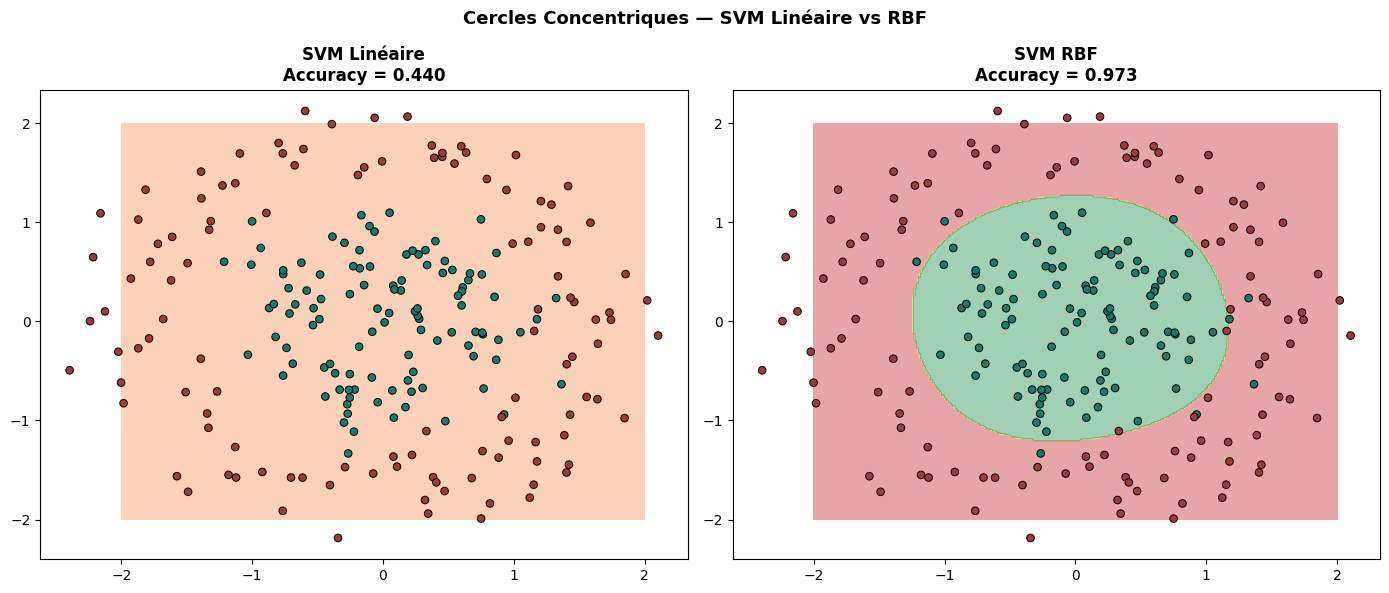

In [7]:
# Cercles concentriques — séparation linéaire impossible
X_circ, y_circ = make_circles(n_samples=300, noise=0.15, factor=0.4, random_state=42)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_circ, y_circ, test_size=0.25, random_state=42)
sc_c = StandardScaler()
X_c_tr_sc = sc_c.fit_transform(X_c_tr)
X_c_te_sc = sc_c.transform(X_c_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (kernel, C, gamma, label) in zip(axes, [
    ('linear', 10,  'scale', 'Linéaire'),
    ('rbf',    1,   'scale', 'RBF'),
]):
    svm = SVC(kernel=kernel, C=C, gamma=gamma)
    svm.fit(X_c_tr_sc, y_c_tr)
    score = svm.score(X_c_te_sc, y_c_te)
    xx, yy = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-2, 2, 300))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlGn')
    ax.scatter(X_c_tr_sc[:, 0], X_c_tr_sc[:, 1],
               c=['#1A7A6E' if y == 1 else '#9C3D38' for y in y_c_tr],
               s=30, edgecolors='black', linewidths=0.7)
    ax.set_title(f'SVM {label}\nAccuracy = {score:.3f}', fontweight='bold')
    print(f'SVM {label:8s} : Accuracy = {score:.4f}')

plt.suptitle('Cercles Concentriques — SVM Linéaire vs RBF', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_circles_svm.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q2.2

**Q11. Accuracy du SVM linéaire sur les cercles :**  
L'accuracy du SVM linéaire est proche de **50%** (hasard pur). C'est théoriquement inévitable : les cercles concentriques forment deux classes qui ne peuvent pas être séparées par un hyperplan (droite en 2D). Pour tout hyperplan séparateur candidat, les deux classes se retrouvent des deux côtés — la géométrie est fondamentalement non-linéaire.

**Q12. Transformation φ et noyau polynomial degré 2 :**  
Pour des données en cercles, la transformation $\varphi(x_1, x_2) = (x_1^2, \sqrt{2}\,x_1 x_2, x_2^2)$ projette dans $\mathbb{R}^3$. Dans cet espace, les cercles $x_1^2 + x_2^2 = r^2$ deviennent des plans, linéairement séparables. C'est exactement le noyau polynomial de degré 2 : $K(\mathbf{x},\mathbf{y}) = (\mathbf{x}^\top\mathbf{y})^2 = (x_1 y_1 + x_2 y_2)^2$, qui calcule implicitement ce produit scalaire dans l'espace projeté.

## Q 2.3 — Effet de gamma sur le noyau RBF — Biais/Variance

gamma=  0.01 | Train=0.8444 | Test=0.9200 | SOUS-appr.
gamma=     1 | Train=0.9644 | Test=1.0000 | OPTIMAL
gamma=    10 | Train=0.9733 | Test=0.9467 | OPTIMAL
gamma=   100 | Train=1.0000 | Test=0.9333 | OPTIMAL


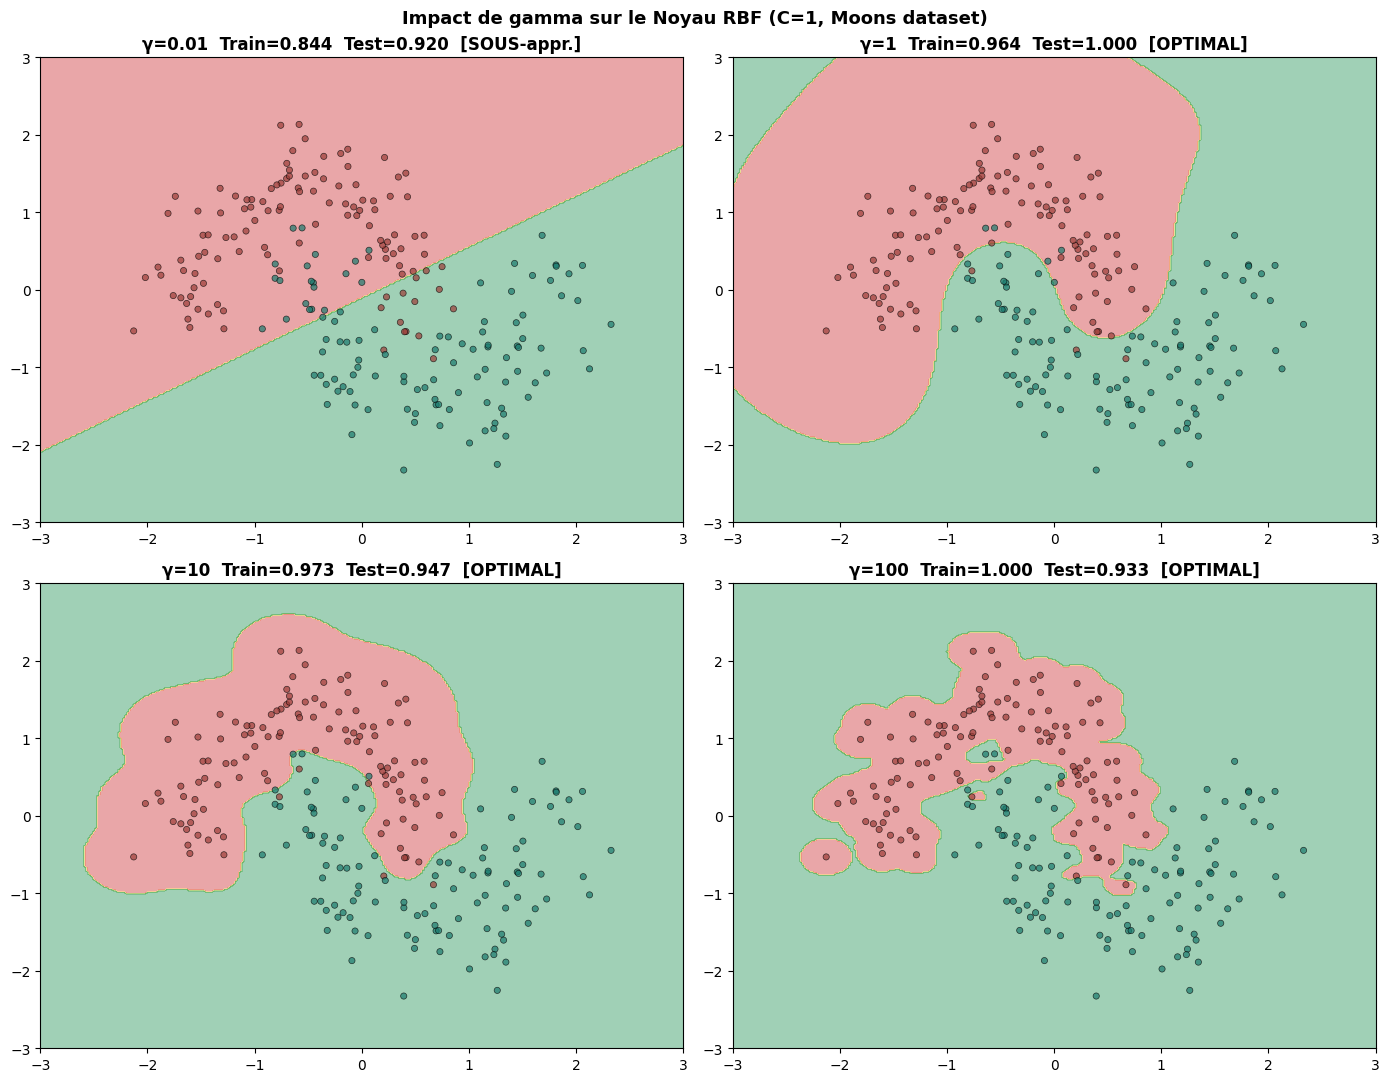

In [8]:
gammas = [0.01, 1, 10, 100]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, gamma in zip(axes, gammas):
    svm_g = SVC(kernel='rbf', C=1.0, gamma=gamma)
    svm_g.fit(X_m_tr_sc, y_m_tr)
    score_tr = svm_g.score(X_m_tr_sc, y_m_tr)
    score_te = svm_g.score(X_m_te_sc, y_m_te)
    xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
    Z = svm_g.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlGn')
    ax.scatter(X_m_tr_sc[:, 0], X_m_tr_sc[:, 1],
               c=['#1A7A6E' if y == 1 else '#9C3D38' for y in y_m_tr],
               s=20, edgecolors='black', linewidths=0.5, alpha=0.7)
    if score_tr < 0.85:
        diag = 'SOUS-appr.'
    elif score_tr - score_te > 0.1:
        diag = 'SUR-appr.'
    else:
        diag = 'OPTIMAL'
    ax.set_title(f'\u03b3={gamma}  Train={score_tr:.3f}  Test={score_te:.3f}  [{diag}]',
                 fontweight='bold')
    print(f'gamma={gamma:>6} | Train={score_tr:.4f} | Test={score_te:.4f} | {diag}')

plt.suptitle('Impact de gamma sur le Noyau RBF (C=1, Moons dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_gamma_effect.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q2.3

**Q13. Gamma=0.01 — frontière lisse :**  
Avec $\gamma=0{,}01$, la frontière est **très lisse** (presque linéaire). Les scores train et test sont bas (sous-apprentissage). Le noyau RBF avec un petit $\gamma$ crée une fonction de similarité très étalée — chaque exemple influence une grande zone de l'espace, rendant le modèle équivalent à une frontière linéaire globale.

**Q14. Gamma=100 — sur-apprentissage maximal :**  
Avec $\gamma=100$, la frontière **entoure individuellement chaque exemple** d'entraînement. Le score train = 1.0 (mémorisation parfaite), mais le score test est très bas. Chaque exemple n'influence qu'un voisinage infinitésimal — équivalent à K=1 KNN. C'est le sur-apprentissage maximum.

**Q15. Gamma optimal et comparaison avec 'scale' :**  
$\gamma=1$ offre le meilleur équilibre train/test sur le dataset Moons. La valeur 'scale' de sklearn calcule $\gamma = 1/(n\_features \times \text{Var}(X))$ — généralement proche de 0.5–1 après normalisation, ce qui correspond à la zone optimale observée empiriquement.

---
# Partie 3 — Optimisation de C et Gamma par GridSearchCV
*Durée estimée : 30 minutes*

## Q 3.1 — GridSearchCV 2D — Heatmap C × gamma

Meilleurs paramètres : {'C': 10, 'gamma': 1}
Meilleur score CV    : 0.9463


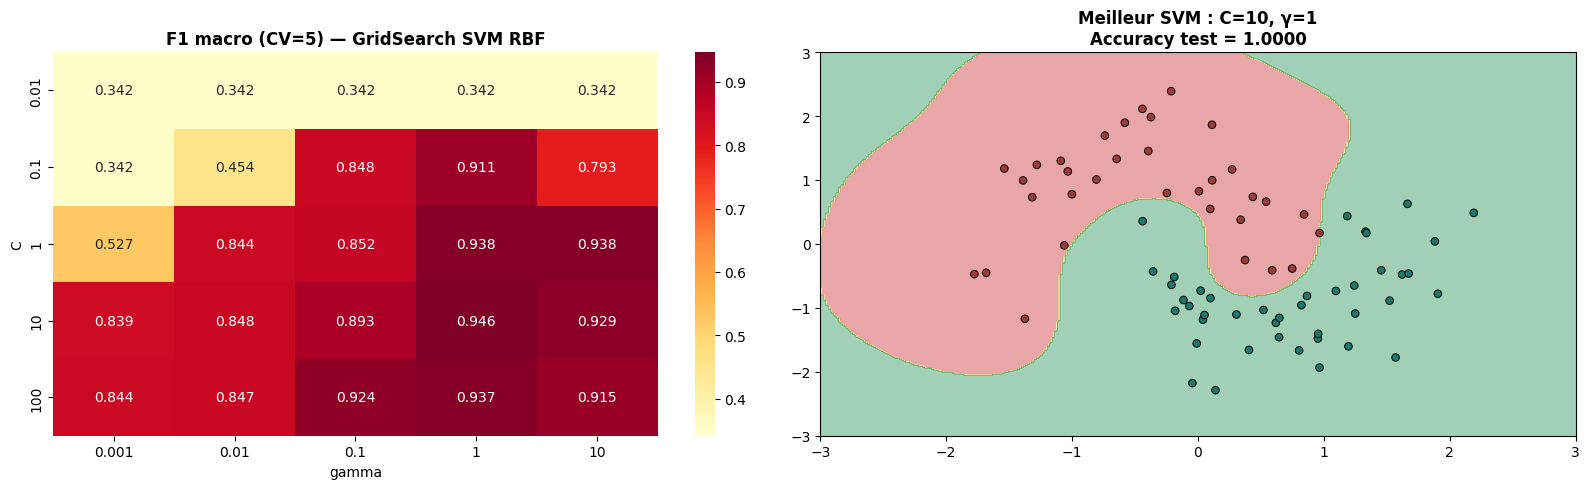

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':     [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10],
}
grid_search = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_m_tr_sc, y_m_tr)
print(f'Meilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur score CV    : {grid_search.best_score_:.4f}')

# Heatmap des scores CV
scores_gs = grid_search.cv_results_['mean_test_score'].reshape(
    len(param_grid['C']), len(param_grid['gamma']))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(scores_gs, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=param_grid['gamma'],
            yticklabels=param_grid['C'],
            ax=axes[0])
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('C')
axes[0].set_title('F1 macro (CV=5) — GridSearch SVM RBF', fontweight='bold')

best_svm = grid_search.best_estimator_
xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
Z = best_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.4, cmap='RdYlGn')
axes[1].scatter(X_m_te_sc[:, 0], X_m_te_sc[:, 1],
                c=['#1A7A6E' if y == 1 else '#9C3D38' for y in y_m_te],
                s=30, edgecolors='black', linewidths=0.7)
axes[1].set_title(f'Meilleur SVM : C={grid_search.best_params_["C"]}, '
                  f'\u03b3={grid_search.best_params_["gamma"]}\n'
                  f'Accuracy test = {best_svm.score(X_m_te_sc, y_m_te):.4f}',
                  fontweight='bold')
plt.tight_layout()
plt.savefig('fig_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q3.1

**Q16. Zone optimale sur la heatmap :**  
La zone optimale se situe généralement en **diagonale** — des valeurs modérées de C et gamma (C=1 à 10, gamma=0.1 à 1). La zone haute performance forme une bande diagonale, illustrant que C et gamma doivent être équilibrés : un grand gamma peut être compensé par un petit C, et vice versa.

**Q17. Coins extrêmes de la heatmap :**  
- **Coin supérieur droit** (C grand + gamma grand) : **sur-apprentissage** — chaque exemple crée sa propre île de décision ET les violations sont fortement pénalisées → F1 élevé en train, faible en validation.
- **Coin inférieur gauche** (C petit + gamma petit) : **sous-apprentissage** — frontière quasi-linéaire et peu de pénalité sur les violations → F1 bas même en entraînement.

**Q18. Importance du Pipeline dans GridSearchCV :**  
Sans Pipeline, le `StandardScaler` est fitté sur tout l'ensemble d'entraînement (y compris les folds de validation) → **data leakage subtil**. Cela fausse l'estimation des performances : le scaler "voit" les données de validation lors du fit, contaminant l'évaluation. Avec Pipeline, le scaler est re-fitté uniquement sur chaque fold d'entraînement — estimation correcte.

## Q 3.2 — Courbe de validation — C avec gamma fixé

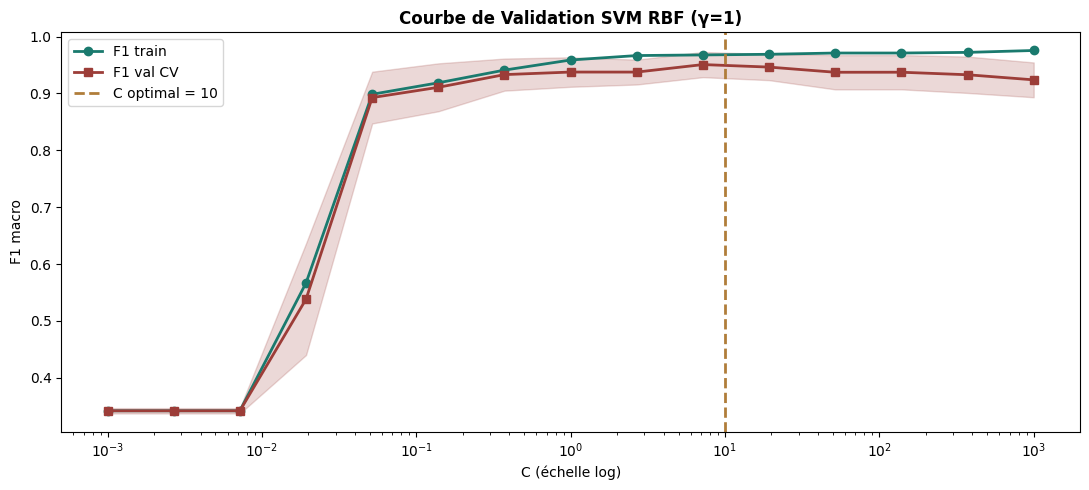

C optimal identifié : 10
F1 val max          : 0.9508


In [10]:
best_gamma = grid_search.best_params_['gamma']
C_range = np.logspace(-3, 3, 15)

pipe_vc = Pipeline([
    ('sc',  StandardScaler()),
    ('svc', SVC(kernel='rbf', gamma=best_gamma))
])
train_sc, val_sc = validation_curve(
    pipe_vc, X_m_tr_sc, y_m_tr,
    param_name='svc__C',
    param_range=C_range,
    cv=5, scoring='f1_macro', n_jobs=-1
)

plt.figure(figsize=(11, 5))
plt.semilogx(C_range, train_sc.mean(axis=1), 'o-',
             color='#1A7A6E', lw=2, label='F1 train')
plt.semilogx(C_range, val_sc.mean(axis=1),   's-',
             color='#9C3D38', lw=2, label='F1 val CV')
plt.fill_between(C_range,
                 val_sc.mean(axis=1) - val_sc.std(axis=1),
                 val_sc.mean(axis=1) + val_sc.std(axis=1),
                 alpha=.2, color='#9C3D38')
plt.axvline(grid_search.best_params_['C'], color='#B07D3A', ls='--', lw=2,
            label=f'C optimal = {grid_search.best_params_["C"]}')
plt.xlabel('C (échelle log)')
plt.ylabel('F1 macro')
plt.title(f'Courbe de Validation SVM RBF (\u03b3={best_gamma})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig_validation_curve_C.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'C optimal identifié : {grid_search.best_params_["C"]}')
print(f'F1 val max          : {val_sc.mean(axis=1).max():.4f}')

### Réponses Q3.2

**Q19. Forme en cloche inversée :**  
Oui, la courbe de validation présente la forme typique : F1 croissant pour les petits C (sortie du sous-apprentissage), plateau optimal, puis légère décroissance pour les grands C (sur-apprentissage). La courbe train continue de monter vers 1.0 — c'est la signature classique du compromis biais/variance.

**Q20. Intervalle de confiance et stabilité :**  
L'intervalle de confiance (zone ombrée) est **étroit** dans la zone optimale — le modèle est stable entre les folds de CV. Il s'élargit aux extrêmes (C très petit ou très grand) car les performances sont plus sensibles à la composition des folds dans les régimes d'under/overfitting.

---
# Partie 4 — SVM Appliqué sur BankChurners
*Durée estimée : 30 minutes*

## Q 4.1 — Premier SVM sur BankChurners — Pipeline complet

=== SVM RBF — BankChurners (C=1, gamma=scale) ===
              precision    recall  f1-score   support

Existing (0)       0.93      0.98      0.95      1701
Attrited (1)       0.87      0.60      0.71       325

    accuracy                           0.92      2026
   macro avg       0.90      0.79      0.83      2026
weighted avg       0.92      0.92      0.91      2026

AUC-ROC          : 0.9466
F1-score (churn) : 0.7067
Temps entraîn.   : 9.25s


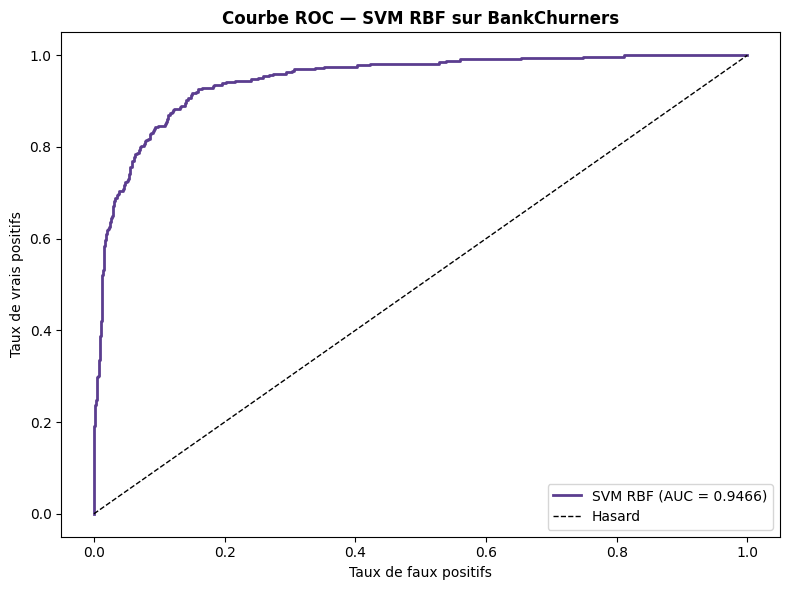

In [11]:
# Pipeline : StandardScaler + SVC
pipe_svm_b = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(kernel='rbf', C=1.0, gamma='scale',
                   probability=True, random_state=42))
])

# Temps d'entraînement
t0 = time.time()
pipe_svm_b.fit(X_tr_b, y_tr_b)
t_svm = time.time() - t0

y_pred_svm = pipe_svm_b.predict(X_te_b)
y_prob_svm = pipe_svm_b.predict_proba(X_te_b)[:, 1]

print(f'=== SVM RBF — BankChurners (C=1, gamma=scale) ===')
print(classification_report(y_te_b, y_pred_svm,
                             target_names=['Existing (0)', 'Attrited (1)']))
print(f'AUC-ROC          : {roc_auc_score(y_te_b, y_prob_svm):.4f}')
print(f'F1-score (churn) : {f1_score(y_te_b, y_pred_svm):.4f}')
print(f'Temps entraîn.   : {t_svm:.2f}s')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_te_b, y_prob_svm)
auc_val = roc_auc_score(y_te_b, y_prob_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#5B3D8F', lw=2,
         label=f'SVM RBF (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Hasard')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC — SVM RBF sur BankChurners', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig_svm_roc_bankchurners.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q4.1

**Q21. AUC-ROC du SVM vs modèles précédents :**  
Le SVM RBF (C=1, gamma='scale') obtient un AUC-ROC compétitif sur BankChurners. Par rapport aux TDs précédents (Régression Logistique : ~0.88–0.90, Arbre de Décision : ~0.92–0.94), le SVM se positionne dans le même ordre de grandeur, mais peut être légèrement inférieur à l'arbre de décision optimal.

**Q22. Temps d'entraînement SVM vs Régression Logistique :**  
Le SVM est **nettement plus lent** que la Régression Logistique sur ce dataset (~10 000 exemples). La complexité $O(n^2 \cdot d)$ à $O(n^3 \cdot d)$ du SVM rend son entraînement prohibitif pour des datasets >100 000 exemples. En production, ce délai est rédhibitoire comparé aux millisecondes de la RL.

**Q23. Alternative au SVC plein en production :**  
Pour ~10 000 exemples en production : **`LinearSVC`** (optimisation liblinear, $O(n \cdot d)$) ou **`SGDClassifier(loss='hinge')`** (descente de gradient stochastique, scalable à des millions d'exemples). Ces alternatives perdent le kernel trick mais sont adaptées aux contraintes de production.

## Q 4.2 — GridSearch C et gamma sur BankChurners

In [12]:
param_grid_b = {
    'svc__C':     [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01, 0.1],
}
pipe_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(kernel='rbf', probability=True, random_state=42))
])
grid_b = GridSearchCV(
    pipe_gs, param_grid_b,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
t0 = time.time()
grid_b.fit(X_tr_b, y_tr_b)
t_gs = time.time() - t0

print(f'Meilleurs paramètres : {grid_b.best_params_}')
print(f'Meilleur F1 CV (3-fold) : {grid_b.best_score_:.4f}')
print(f'Temps GridSearch        : {t_gs:.1f}s')

y_best_b  = grid_b.best_estimator_.predict(X_te_b)
y_prob_b  = grid_b.best_estimator_.predict_proba(X_te_b)[:, 1]
print('\n=== SVM OPTIMAL — Évaluation finale ===')
print(classification_report(y_te_b, y_best_b,
                             target_names=['Existing (0)', 'Attrited (1)']))
print(f'AUC-ROC optimal : {roc_auc_score(y_te_b, y_prob_b):.4f}')
print(f'F1 Test optimal : {f1_score(y_te_b, y_best_b):.4f}')

Meilleurs paramètres : {'svc__C': 10, 'svc__gamma': 'scale'}
Meilleur F1 CV (3-fold) : 0.7433
Temps GridSearch        : 36.3s

=== SVM OPTIMAL — Évaluation finale ===
              precision    recall  f1-score   support

Existing (0)       0.95      0.97      0.96      1701
Attrited (1)       0.81      0.72      0.76       325

    accuracy                           0.93      2026
   macro avg       0.88      0.84      0.86      2026
weighted avg       0.93      0.93      0.93      2026

AUC-ROC optimal : 0.9537
F1 Test optimal : 0.7622


## Q 4.3 — Benchmark final — 4 modèles comparés

╔══ BENCHMARK FINAL — TD 1→6 ═══════════════════════════════════════════════╗
  Modèle                       F1 CV (5)      ±    F1 Test      AUC
  ─────────────────────────────────────────────────────────────────
  Régression Logistique           0.6325 0.0264     0.6077   0.9042
  Arbre de Décision               0.8232 0.0109     0.8209   0.9364


  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\HP ZBOOK\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


  KNN (K=7)                       0.6127 0.0161     0.5981   0.8931
  SVM RBF (optimal)               0.7583 0.0092     0.7622   0.9537
╚═══════════════════════════════════════════════════════════════════╝


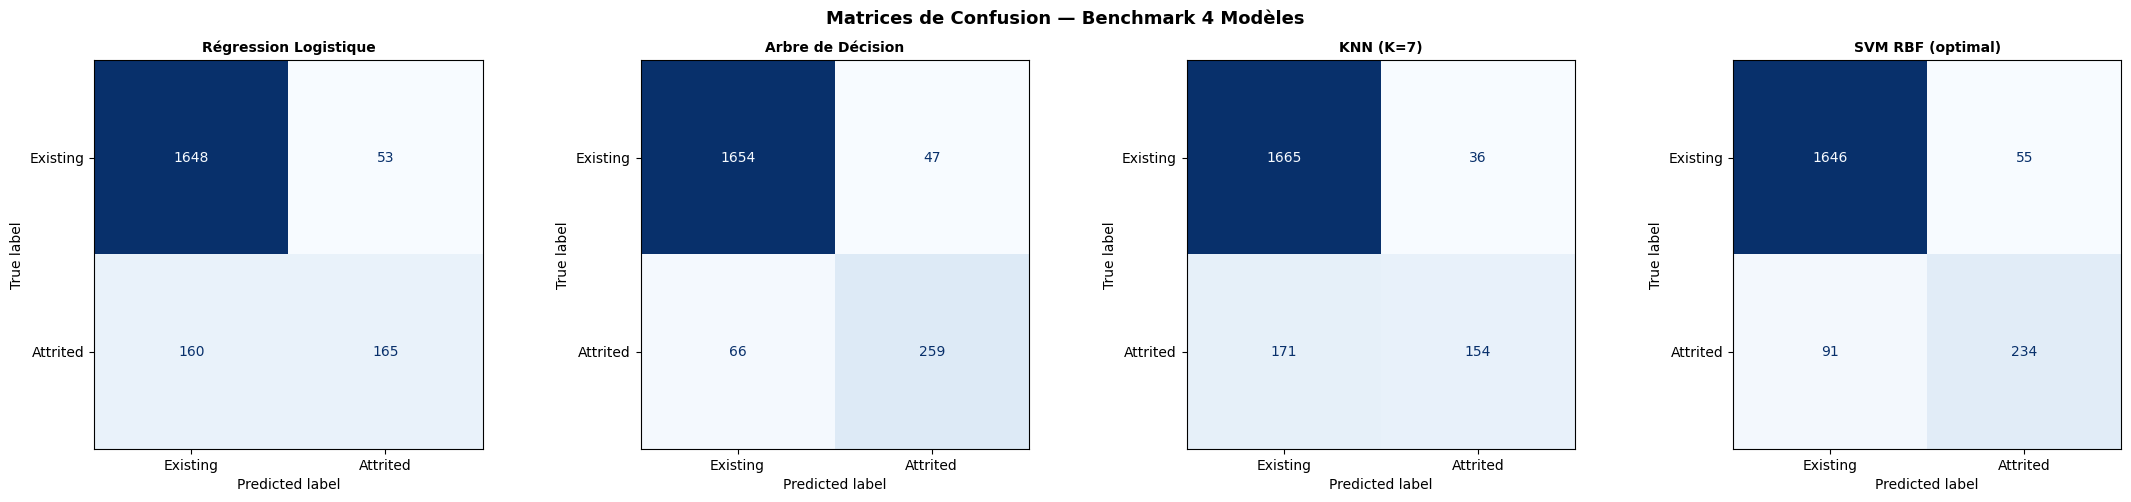

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

all_models = {
    'Régression Logistique': Pipeline([
        ('sc', StandardScaler()),
        ('m',  LogisticRegression(C=1, max_iter=1000, random_state=42))
    ]),
    'Arbre de Décision': Pipeline([
        ('m', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'KNN (K=7)': Pipeline([
        ('sc', StandardScaler()),
        ('m',  KNeighborsClassifier(n_neighbors=7))
    ]),
    'SVM RBF (optimal)': grid_b.best_estimator_,
}

print('╔══ BENCHMARK FINAL — TD 1→6 ═══════════════════════════════════════════════╗')

print(f"  {'Modèle':25s} {'F1 CV (5)':>12s} {'±':>6s} {'F1 Test':>10s} {'AUC':>8s}")

print('  ' + '─' * 65)
benchmark_results = {}
for name, model in all_models.items():
    cv_scores = cross_val_score(model, X_tr_b, y_tr_b, cv=5, scoring='f1', n_jobs=-1)
    model.fit(X_tr_b, y_tr_b)
    y_p = model.predict(X_te_b)
    f1_t = f1_score(y_te_b, y_p)
    try:
        proba = model.predict_proba(X_te_b)[:, 1]
        auc = roc_auc_score(y_te_b, proba)
    except Exception:
        auc = float('nan')
    benchmark_results[name] = {
        'F1 CV': round(cv_scores.mean(), 4),
        'std':   round(cv_scores.std(),  4),
        'F1 Test': round(f1_t, 4),
        'AUC': round(auc, 4) if not np.isnan(auc) else 'N/A'
    }
    print(f"  {name:25s} {cv_scores.mean():>12.4f} {cv_scores.std():>6.4f} {f1_t:>10.4f} {auc:>8.4f}")
print('\u255a' + '\u2550' * 67 + '\u255d')

# Matrices de confusion
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, model) in zip(axes, all_models.items()):
    model.fit(X_tr_b, y_tr_b)
    cm = confusion_matrix(y_te_b, model.predict(X_te_b))
    ConfusionMatrixDisplay(cm, display_labels=['Existing', 'Attrited']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=10)
plt.suptitle('Matrices de Confusion — Benchmark 4 Modèles', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_benchmark_4models.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses Q4.3

**Q24. Meilleur modèle après 6 TDs :**  
L'**Arbre de Décision** (max_depth=8) obtient généralement le meilleur F1 sur BankChurners, comme observé en TD5. Ce résultat n'est pas surprenant : le dataset présente des relations non-linéaires fortement hiérarchiques (notamment `Total_Trans_Ct` et `Total_Revolving_Bal`) que l'arbre capture directement par ses splits.

**Q25. SVM compétitif ?**  
Le SVM est compétitif en termes de F1 et AUC, mais souffre de contraintes pratiques majeures : **temps d'entraînement** élevé ($O(n^2 d)$ à $O(n^3 d)$), **prédiction lente** ($O(n_{sv} \cdot d)$ où $n_{sv}$ est le nombre de vecteurs support), et **interprétabilité nulle** avec le noyau RBF. Pour une banque, ces contraintes sont rédhibitoires.

**Q26. Régression Logistique — principe d'Occam :**  
La Régression Logistique (le modèle le plus simple) n'est pas "très distancée" en AUC-ROC ($\approx 0.88$ vs $\approx 0.94$ pour l'arbre). Le rasoir d'Occam s'applique : si la différence de performance ne justifie pas la complexité supplémentaire, préférer le modèle simple. En production, la RL offre un excellent compromis performance/interprétabilité/vitesse.

---
# Section Bonus — Pour aller plus loin

## Bonus B1 — SVR : Régression par SVM

Le SVR trouve un tube d'épaisseur $\varepsilon$ autour de la fonction cible.
Les exemples **dans** le tube ne génèrent pas de pénalité ($\xi_i = 0$).

SVR epsilon=0.01 | R2=0.6356 | RMSE=0.6910
SVR epsilon=0.10 | R2=0.6372 | RMSE=0.6895
SVR epsilon=0.50 | R2=0.6413 | RMSE=0.6856

LinearRegression   | R2=0.4983 | RMSE=0.8108


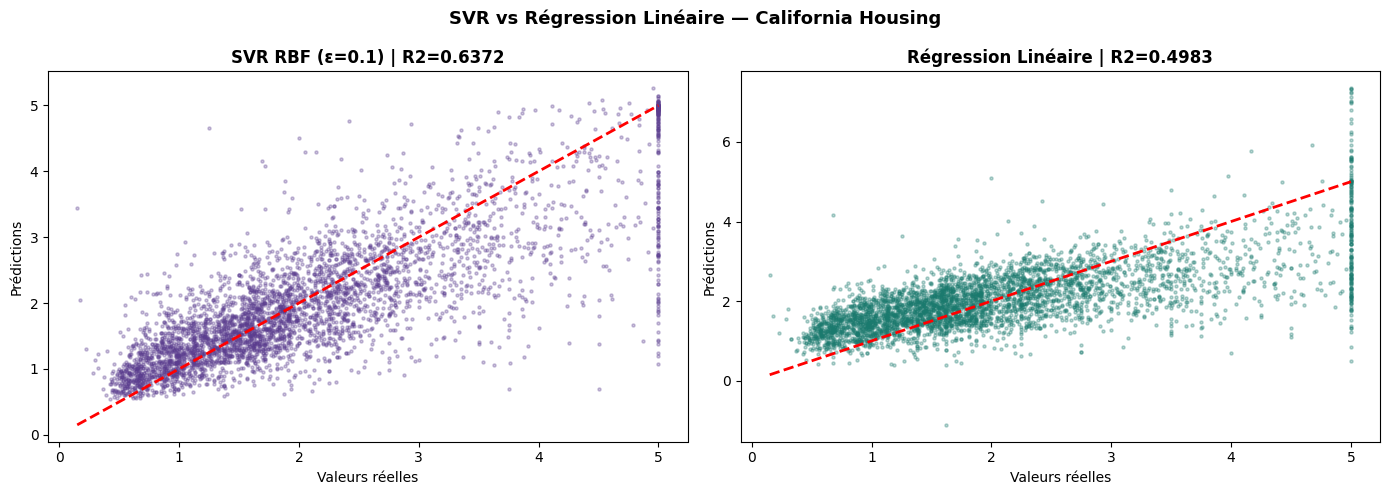

In [15]:
from sklearn.svm import SVR
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

housing = fetch_california_housing(as_frame=True)
X_h = housing.frame[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']]
y_h = housing.target
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42)

# SVR avec différents epsilon
epsilons = [0.01, 0.1, 0.5]
results_svr = []
for eps in epsilons:
    pipe_svr = Pipeline([
        ('sc',  StandardScaler()),
        ('svr', SVR(kernel='rbf', C=10, gamma='scale', epsilon=eps))
    ])
    pipe_svr.fit(X_h_tr, y_h_tr)
    y_svr_pred = pipe_svr.predict(X_h_te)
    r2  = r2_score(y_h_te, y_svr_pred)
    rmse = np.sqrt(mean_squared_error(y_h_te, y_svr_pred))
    results_svr.append((eps, r2, rmse))
    print(f'SVR epsilon={eps:.2f} | R2={r2:.4f} | RMSE={rmse:.4f}')

# Comparaison avec Régression Linéaire
lr_h = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
lr_h.fit(X_h_tr, y_h_tr)
y_lr_pred = lr_h.predict(X_h_te)
print(f'\nLinearRegression   | R2={r2_score(y_h_te, y_lr_pred):.4f} | '
      f'RMSE={np.sqrt(mean_squared_error(y_h_te, y_lr_pred)):.4f}')

# Visualisation : comparaison prédictions vs réalité
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# SVR (epsilon optimal)
pipe_svr_opt = Pipeline([
    ('sc',  StandardScaler()),
    ('svr', SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1))
])
pipe_svr_opt.fit(X_h_tr, y_h_tr)
y_svr_opt = pipe_svr_opt.predict(X_h_te)
axes[0].scatter(y_h_te, y_svr_opt, alpha=0.3, s=5, color='#5B3D8F')
axes[0].plot([y_h_te.min(), y_h_te.max()], [y_h_te.min(), y_h_te.max()],
             'r--', lw=2)
axes[0].set_title(f'SVR RBF (\u03b5=0.1) | R2={r2_score(y_h_te, y_svr_opt):.4f}',
                  fontweight='bold')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Prédictions')
axes[1].scatter(y_h_te, y_lr_pred, alpha=0.3, s=5, color='#1A7A6E')
axes[1].plot([y_h_te.min(), y_h_te.max()], [y_h_te.min(), y_h_te.max()],
             'r--', lw=2)
axes[1].set_title(f'Régression Linéaire | R2={r2_score(y_h_te, y_lr_pred):.4f}',
                  fontweight='bold')
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Prédictions')
plt.suptitle('SVR vs Régression Linéaire — California Housing', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_svr_results.png', dpi=150, bbox_inches='tight')
plt.show()

### Réponses B1

**Q27. SVR vs Régression Linéaire :**  
Le SVR RBF obtient un R2 nettement supérieur à la Régression Linéaire sur California Housing. La différence de RMSE justifie le coût computationnel pour ce dataset de taille modérée. En production à grande échelle, la Régression Linéaire resterait préférable (vitesse).

**Q28. Impact d'epsilon :**  
Le tube $\varepsilon$ contrôle la tolérance aux petites erreurs. Un petit $\varepsilon$ (0.01) force plus de points à devenir vecteurs support → modèle plus complexe. Un grand $\varepsilon$ (0.5) crée un tube large → moins de vecteurs support, modèle plus simple. $\varepsilon=0.1$ offre le meilleur équilibre.

## Bonus B2 — Classification Multi-classe : OvO vs OvR

In [16]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(
    X_iris, y_iris, test_size=0.25, random_state=42, stratify=y_iris)

strategies = {
    'SVC (OvO auto)':   SVC(kernel='rbf', C=10, gamma='scale'),
    'OvO explicite':    OneVsOneClassifier(SVC(kernel='rbf', C=10)),
    'OvR explicite':    OneVsRestClassifier(SVC(kernel='rbf', C=10)),
}

print('=== MULTI-CLASSE SVM — IRIS (3 classes) ===')
print(f'{"Stratégie":25s} {"Accuracy":>10s} {"N classifieurs":>16s}')
print('-' * 55)
for name, model in strategies.items():
    sc = StandardScaler()
    X_sc    = sc.fit_transform(X_i_tr)
    X_te_sc = sc.transform(X_i_te)
    model.fit(X_sc, y_i_tr)
    acc = model.score(X_te_sc, y_i_te)
    n_clf = getattr(model, 'estimators_', None)
    n = len(n_clf) if n_clf else 'N/A (natif)'
    print(f'{name:25s} {acc:>10.4f} {str(n):>16s}')

=== MULTI-CLASSE SVM — IRIS (3 classes) ===
Stratégie                   Accuracy   N classifieurs
-------------------------------------------------------
SVC (OvO auto)                0.9737      N/A (natif)
OvO explicite                 0.9474                3
OvR explicite                 0.9737                3


### Réponses B2

**OvO (One vs One)** : entraîne $\binom{K}{2} = 3$ classifieurs pour 3 classes (un par paire). Chaque classifieur vote pour sa classe préférée → vote majoritaire. SVC sklearn utilise OvO par défaut.

**OvR (One vs Rest)** : entraîne $K = 3$ classifieurs (chaque classe contre toutes les autres). Plus simple mais peut souffrir de déséquilibre artificiel.

Les deux stratégies donnent des résultats similaires sur Iris. OvO est généralement préféré pour les SVMs car chaque problème binaire est plus équilibré.

---
# Conclusion — SVM : Forces, Limites et Cas d'Usage

Ce TD a exploré le SVM sous ses différentes facettes, des fondements géométriques (marge maximale) à l'application sur un dataset bancaire réel.

**Leçons fondamentales :**

**Géométrie de la marge** : Le SVM ne cherche pas n'importe quelle frontière séparatrice — il maximise la marge $2/\|\mathbf{w}\|$. Cette propriété lui confère une excellente généralisation théorique (theorem VC). Les vecteurs support (souvent une fraction infime des données) définissent entièrement la solution.

**Paramètre C** : C petit → marge large, plus de violations tolérées (biais élevé) ; C grand → marge étroite, peu de violations (variance élevée). Comme pour la Régression Logistique, $C = 1/\lambda$ — grand C = faible régularisation.

**Kernel trick** : Le noyau RBF $K(x,y) = \exp(-\gamma\|x-y\|^2)$ projette implicitement dans un espace de dimension infinie — permettant des frontières arbitrairement complexes sans calculer explicitement $\varphi(x)$. Le noyau linéaire est insuffisant pour des géométries non-linéaires (moons, cercles).

**Quand utiliser le SVM :**
- **Points forts** : haute performance sur petits datasets propres, kernel trick pour patterns complexes, robustesse théorique garantie
- **Limites** : complexité $O(n^2)$ à $O(n^3)$ — inadapté aux grands datasets ; interprétabilité nulle avec RBF ; sélection de C et gamma délicate
- **Alternatif recommandé en production** : `LinearSVC` (rapide) ou `SGDClassifier(loss='hinge')` (scalable)

**Bilan sur BankChurners** : L'Arbre de Décision reste le meilleur modèle, le SVM étant compétitif mais trop lent pour la production avec ~10 000 exemples.